In [1]:
!pip install -q "sentence-transformers>=3.0.0" datasets accelerate


In [2]:
import torch
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, Dataset
from huggingface_hub import notebook_login



In [3]:
pd.set_option('display.max_colwidth', 150)
notebook_login()

In [4]:
# ============================================================
# 2. CARGA DEL DATASET
# ============================================================
dataset = load_dataset("wilfredomartel/TripLegal-CL", split="train")
print(f"Total de registros: {len(dataset):,}")
print(f"Columnas: {dataset.column_names}")
print(f"Features: {dataset.features}")

df = dataset.to_pandas()
print(f"Shape: {df.shape}")


README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

spanish-legal-dataset.jsonl:   0%|          | 0.00/2.17G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Total de registros: 606,962
Columnas: ['query', 'pos', 'neg', 'pos_score', 'neg_score']
Features: {'query': Value('string'), 'pos': List(Value('string')), 'neg': List(Value('string')), 'pos_score': List(Value('float64')), 'neg_score': List(Value('float64'))}
Shape: (606962, 5)


In [5]:
# ============================================================
# 3. DIAGNÓSTICO DE ESTRUCTURA
# ============================================================
print("=" * 60)
print("DIAGNÓSTICO DE ESTRUCTURA")
print("=" * 60)

# pos y neg
row_pos = df['pos'].iloc[0]
row_neg = df['neg'].iloc[0]
print(f"pos -> Tipo: {type(row_pos)}, len: {len(row_pos)}, elemento[0][:80]: {str(row_pos[0])[:80]}")
print(f"neg -> Tipo: {type(row_neg)}, len: {len(row_neg)}, elemento[0][:80]: {str(row_neg[0])[:80]}")

# scores
print(f"\npos_score -> Tipo: {type(df['pos_score'].iloc[0])}, ejemplo: {repr(df['pos_score'].iloc[0])}")
print(f"neg_score -> Tipo: {type(df['neg_score'].iloc[0])}, ejemplo: {repr(df['neg_score'].iloc[0])}")

DIAGNÓSTICO DE ESTRUCTURA
pos -> Tipo: <class 'numpy.ndarray'>, len: 2, elemento[0][:80]: La Corte Constitucional inadmitió a trámite la acción extraordinaria de protecci
neg -> Tipo: <class 'numpy.ndarray'>, len: 2, elemento[0][:80]: La Corte Constitucional inadmitió la acción extraordinaria de protección N° 2850

pos_score -> Tipo: <class 'numpy.ndarray'>, ejemplo: array([95., 93.])
neg_score -> Tipo: <class 'numpy.ndarray'>, ejemplo: array([55., 58.])


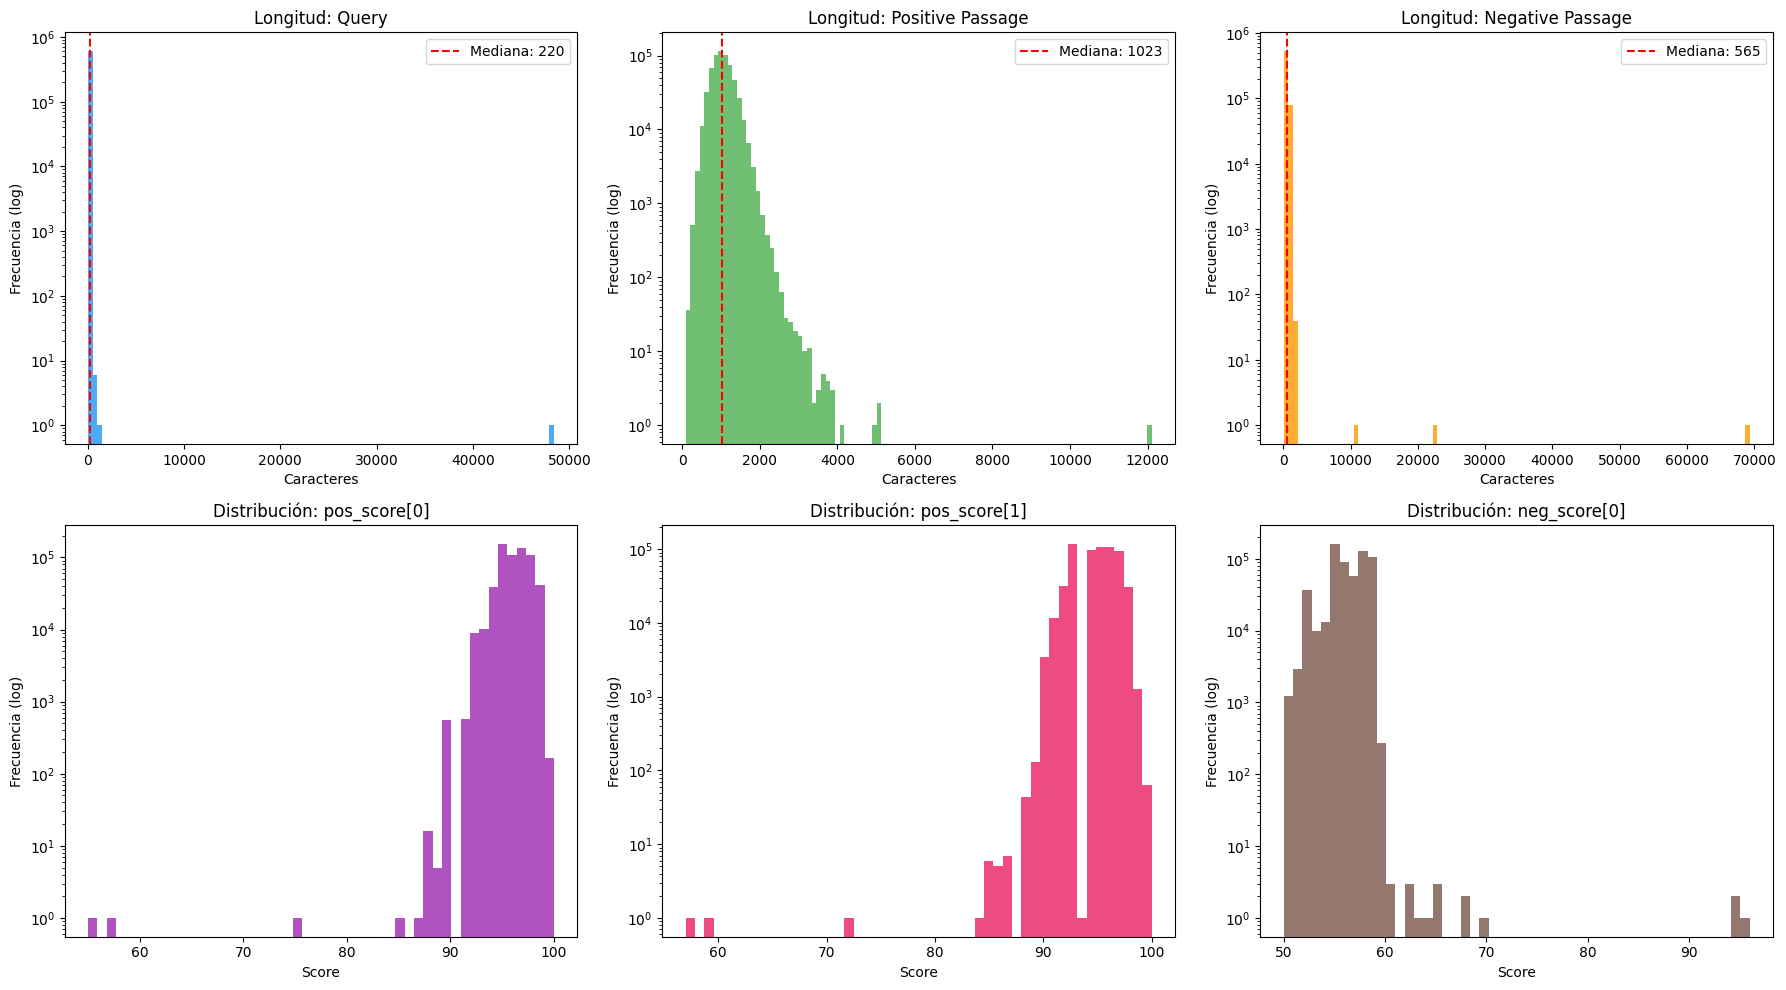

In [6]:
df['query_len'] = df['query'].astype(str).apply(len)
df['pos_len'] = df['pos'].apply(lambda x: len(x[0]) if x is not None and len(x) > 0 else 0)
df['neg_len'] = df['neg'].apply(lambda x: len(x[0]) if x is not None and len(x) > 0 else 0)

df['pos_score_len'] = df['pos_score'].apply(len)
df['neg_score_len'] = df['neg_score'].apply(len)

df['pos_score_0'] = df['pos_score'].apply(lambda x: x[0] if x is not None and len(x) > 0 else np.nan)
df['pos_score_1'] = df['pos_score'].apply(lambda x: x[1] if x is not None and len(x) > 1 else np.nan)
df['neg_score_0'] = df['neg_score'].apply(lambda x: x[0] if x is not None and len(x) > 0 else np.nan)
df['neg_score_1'] = df['neg_score'].apply(lambda x: x[1] if x is not None and len(x) > 1 else np.nan)


# 4.4 Histogramas de distribución
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Fila 1: Longitudes de texto
for i, (col, title) in enumerate([
    ('query_len', 'Query'), ('pos_len', 'Positive Passage'), ('neg_len', 'Negative Passage')
]):
    axes[0][i].hist(df[col], bins=100, log=True, color=['#2196F3', '#4CAF50', '#FF9800'][i], alpha=0.8)
    axes[0][i].set_title(f'Longitud: {title}')
    axes[0][i].set_xlabel('Caracteres')
    axes[0][i].set_ylabel('Frecuencia (log)')
    axes[0][i].axvline(df[col].median(), color='red', linestyle='--', label=f'Mediana: {df[col].median():.0f}')
    axes[0][i].legend()

# Fila 2: Scores
for i, (col, title) in enumerate([
    ('pos_score_0', 'pos_score[0]'), ('pos_score_1', 'pos_score[1]'), ('neg_score_0', 'neg_score[0]')
]):
    axes[1][i].hist(df[col].dropna(), bins=50, log=True, color=['#9C27B0', '#E91E63', '#795548'][i], alpha=0.8)
    axes[1][i].set_title(f'Distribución: {title}')
    axes[1][i].set_xlabel('Score')
    axes[1][i].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 5. DEFINIR UMBRALES Y DETECTAR ANOMALÍAS
# ============================================================

# ⚠️ UMBRALES - Basados en análisis de percentiles e histogramas
QUERY_MIN_LEN = 50
QUERY_MAX_LEN = 400      # P99.9 = 382
POS_MIN_LEN   = 100      # Min actual = 89
POS_MAX_LEN   = 2500     # P99.9 = 2236
NEG_MIN_LEN   = 100      # Min actual = 66
NEG_MAX_LEN   = 1500     # P99.9 = 1214

print("=" * 60)
print("UMBRALES CONFIGURADOS")
print("=" * 60)
print(f"  Query:     [{QUERY_MIN_LEN}, {QUERY_MAX_LEN}] caracteres")
print(f"  Pos:       [{POS_MIN_LEN}, {POS_MAX_LEN}] caracteres")
print(f"  Neg:       [{NEG_MIN_LEN}, {NEG_MAX_LEN}] caracteres")
print(f"  Scores:    arrays de exactamente 2 floats, sin NaN")


UMBRALES CONFIGURADOS
  Query:     [50, 400] caracteres
  Pos:       [100, 2500] caracteres
  Neg:       [100, 1500] caracteres
  Scores:    arrays de exactamente 2 floats, sin NaN


In [8]:
# Detectar anomalías
anomalias = {
    # --- Longitud de texto ---
    'query_muy_largo':     df['query_len'] > QUERY_MAX_LEN,
    'query_muy_corto':     df['query_len'] < QUERY_MIN_LEN,
    'pos_muy_largo':       df['pos_len'] > POS_MAX_LEN,
    'pos_muy_corto':       df['pos_len'] < POS_MIN_LEN,
    'neg_muy_largo':       df['neg_len'] > NEG_MAX_LEN,
    'neg_muy_corto':       df['neg_len'] < NEG_MIN_LEN,
    # --- Listas vacías ---
    'pos_vacio':           df['pos'].apply(lambda x: len(x) == 0),
    'neg_vacio':           df['neg'].apply(lambda x: len(x) == 0),
    # --- Scores con estructura incorrecta ---
    'pos_score_len_mal':   df['pos_score_len'] != 2,
    'neg_score_len_mal':   df['neg_score_len'] != 2,
    # --- Scores con NaN ---
    'pos_score_nan':       df['pos_score_0'].isna() | df['pos_score_1'].isna(),
    'neg_score_nan':       df['neg_score_0'].isna() | df['neg_score_1'].isna(),
}

print("\n" + "=" * 60)
print("CONTEO DE ANOMALÍAS POR TIPO")
print("=" * 60)
total_anomalos = pd.Series(False, index=df.index)
for nombre, mascara in anomalias.items():
    count = mascara.sum()
    pct = count / len(df) * 100
    print(f"  {nombre:25s}: {count:>6,} registros ({pct:.4f}%)")
    total_anomalos = total_anomalos | mascara


CONTEO DE ANOMALÍAS POR TIPO
  query_muy_largo          :    268 registros (0.0442%)
  query_muy_corto          :      1 registros (0.0002%)
  pos_muy_largo            :    189 registros (0.0311%)
  pos_muy_corto            :      1 registros (0.0002%)
  neg_muy_largo            :     29 registros (0.0048%)
  neg_muy_corto            :      2 registros (0.0003%)
  pos_vacio                :      0 registros (0.0000%)
  neg_vacio                :      0 registros (0.0000%)
  pos_score_len_mal        :    344 registros (0.0567%)
  neg_score_len_mal        :    293 registros (0.0483%)
  pos_score_nan            :    294 registros (0.0484%)
  neg_score_nan            :    288 registros (0.0474%)


In [9]:
# Duplicados
n_dup = df.duplicated(subset=['query'], keep='first').sum()
print(f"  {'duplicados_query':25s}: {n_dup:>6,} registros ({n_dup/len(df)*100:.4f}%)")

# Nulos y vacíos
n_nulos = df[['query']].isnull().any(axis=1).sum()
n_vacios = (df['query'].astype(str).str.strip() == '').sum()
print(f"  {'query_nulo':25s}: {n_nulos:>6,} registros")
print(f"  {'query_vacio':25s}: {n_vacios:>6,} registros")

total_con_dup = total_anomalos | df.duplicated(subset=['query'], keep='first')
print(f"\n  {'TOTAL A ELIMINAR':25s}: {total_con_dup.sum():>6,} registros ({total_con_dup.sum()/len(df)*100:.4f}%)")
print(f"  {'REGISTROS QUE QUEDAN':25s}: {(~total_con_dup).sum():>6,} registros")

  duplicados_query         : 13,610 registros (2.2423%)
  query_nulo               :      0 registros
  query_vacio              :      0 registros

  TOTAL A ELIMINAR         : 14,427 registros (2.3769%)
  REGISTROS QUE QUEDAN     : 592,535 registros


In [10]:
# ============================================================
# 5.1 Inspección visual de anomalías
# ============================================================
for nombre, mascara in anomalias.items():
    subset = df[mascara]
    if len(subset) > 0:
        print(f"\n{'='*60}")
        print(f"EJEMPLO de '{nombre}' ({len(subset)} registros)")
        print(f"{'='*60}")
        row = subset.iloc[0]
        print(f"  query_len={row['query_len']}, pos_len={row['pos_len']}, neg_len={row['neg_len']}")
        print(f"  pos_score={repr(row['pos_score'])}, neg_score={repr(row['neg_score'])}")
        print(f"  query: {str(row['query'])[:200]}...")
    else:
        print(f"\n✅ Sin anomalías para '{nombre}'")


EJEMPLO de 'query_muy_largo' (268 registros)
  query_len=409, pos_len=1675, neg_len=1144
  pos_score=array([95., 93.]), neg_score=array([58., 59.])
  query: ¿Cuáles fueron las razones específicas por las cuales la Sala de Admisión de la Corte Constitucional del Ecuador inadmitió la acción extraordinaria de protección N°. 0005-20-EP, interpuesta por Luis G...

EJEMPLO de 'query_muy_corto' (1 registros)
  query_len=29, pos_len=868, neg_len=515
  pos_score=array([95., 96.]), neg_score=array([55., 58.])
  query: ¿Cuál es el propósito de las ...

EJEMPLO de 'pos_muy_largo' (189 registros)
  query_len=212, pos_len=3183, neg_len=537
  pos_score=array([98., 96.]), neg_score=array([55., 57.])
  query: ¿En qué casos la Corte Suprema de Justicia, Segunda Sala de lo Laboral y Social, aceptó el recurso de casación en los juicios laborales presentados en octubre y noviembre de 2000, y cuáles fueron los ...

EJEMPLO de 'pos_muy_corto' (1 registros)
  query_len=235, pos_len=89, neg_len=66
  pos_score

In [11]:
# ============================================================
# 6. APLICAR LIMPIEZA
# ============================================================
print("\n" + "=" * 60)
print("APLICANDO LIMPIEZA...")
print("=" * 60)

mask_eliminar = pd.Series(False, index=df.index)

# 1. Anomalías por longitud, listas vacías y scores
for nombre, mascara in anomalias.items():
    mask_eliminar = mask_eliminar | mascara

# 2. Duplicados (conservar primera aparición)
mask_eliminar = mask_eliminar | df.duplicated(subset=['query'], keep='first')

# 3. Nulos y vacíos en query
mask_eliminar = mask_eliminar | df[['query']].isnull().any(axis=1)
mask_eliminar = mask_eliminar | (df['query'].astype(str).str.strip() == '')


# 4. Listas pos/neg con más de 5 elementos
df['_pos_list_len'] = df['pos'].apply(len)
df['_neg_list_len'] = df['neg'].apply(len)

print("\nDistribución de elementos en pos:")
print(df['_pos_list_len'].value_counts().sort_index())
print("\nDistribución de elementos en neg:")
print(df['_neg_list_len'].value_counts().sort_index())

mask_pos_larga = df['_pos_list_len'] > 4
mask_neg_larga = df['_neg_list_len'] > 3
print(f"\nRegistros con pos > 5 elementos: {mask_pos_larga.sum():,}")
print(f"Registros con neg > 5 elementos: {mask_neg_larga.sum():,}")

mask_eliminar = mask_eliminar | mask_pos_larga | mask_neg_larga

# Resumen
print(f"  Registros originales:  {len(df):>10,}")
print(f"  Registros a eliminar:  {mask_eliminar.sum():>10,}")
print(f"  Registros restantes:   {(~mask_eliminar).sum():>10,}")
print(f"  Porcentaje eliminado:  {mask_eliminar.sum()/len(df)*100:.2f}%")

# Aplicar filtro y limpiar columnas auxiliares
cols_auxiliares = ['query_len', 'pos_len', 'neg_len', 'pos_score_len', 'neg_score_len',
                   'pos_score_0', 'pos_score_1', 'neg_score_0', 'neg_score_1','_pos_list_len','_neg_list_len']
df_limpio = df[~mask_eliminar].drop(columns=cols_auxiliares).copy()
print(f"\nDataset limpio: {len(df_limpio):,} registros")
print(f"Columnas finales: {list(df_limpio.columns)}")


APLICANDO LIMPIEZA...

Distribución de elementos en pos:
_pos_list_len
1        441
2     606037
3        211
4        121
5         98
6         35
7          2
8          8
9          2
11         2
13         1
14         3
22         1
Name: count, dtype: int64

Distribución de elementos en neg:
_neg_list_len
1       331
2    606604
3         7
4         8
5        11
6         1
Name: count, dtype: int64

Registros con pos > 5 elementos: 152
Registros con neg > 5 elementos: 20
  Registros originales:     606,962
  Registros a eliminar:      14,580
  Registros restantes:      592,382
  Porcentaje eliminado:  2.40%

Dataset limpio: 592,382 registros
Columnas finales: ['query', 'pos', 'neg', 'pos_score', 'neg_score']



VALIDACIÓN POST-LIMPIEZA

Query length:
count    592382.000000
mean        222.273334
std          41.700614
min          50.000000
25%         193.000000
50%         220.000000
75%         249.000000
max         400.000000

Pos length:
count    592382.000000
mean       1043.707359
std         265.085832
min         142.000000
25%         862.000000
50%        1025.000000
75%        1203.000000
max        2500.000000

Neg length:
count    592382.000000
mean        581.216661
std         157.825287
min         108.000000
25%         470.000000
50%         567.000000
75%         675.000000
max        1499.000000

✅ TODAS LAS VALIDACIONES PASARON CORRECTAMENTE


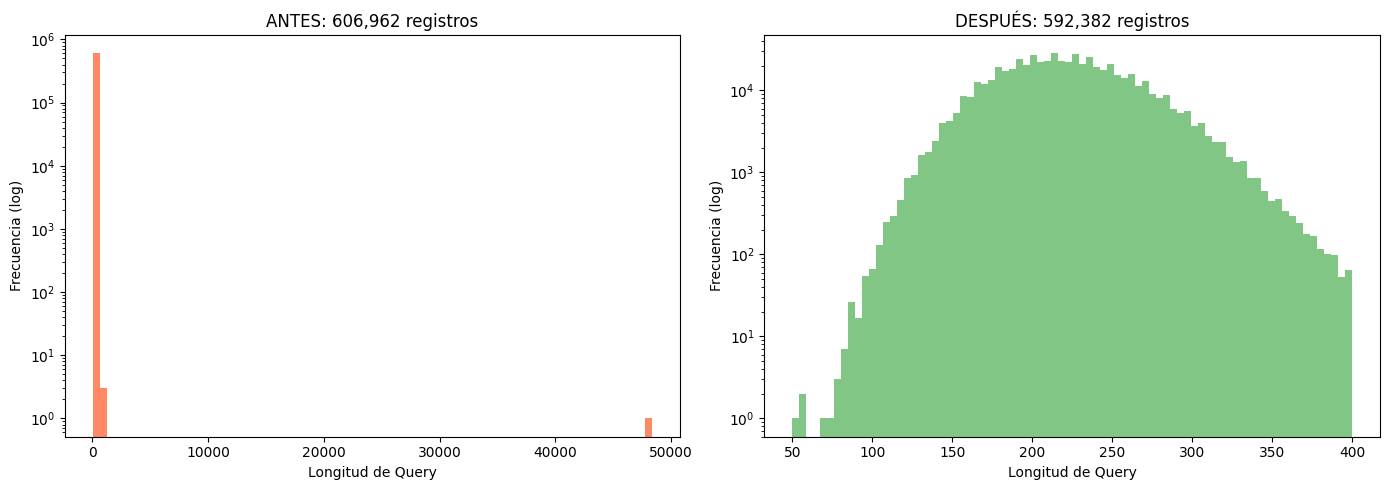

In [12]:
# ============================================================
# 7. VALIDACIÓN POST-LIMPIEZA
# ============================================================
print("\n" + "=" * 60)
print("VALIDACIÓN POST-LIMPIEZA")
print("=" * 60)

# Recalcular métricas sobre el dataset limpio
df_limpio['_q'] = df_limpio['query'].astype(str).apply(len)
df_limpio['_p'] = df_limpio['pos'].apply(lambda x: len(x[0]) if len(x) > 0 else 0)
df_limpio['_n'] = df_limpio['neg'].apply(lambda x: len(x[0]) if len(x) > 0 else 0)
df_limpio['_ps_len'] = df_limpio['pos_score'].apply(len)
df_limpio['_ns_len'] = df_limpio['neg_score'].apply(len)

print("\nQuery length:")
print(df_limpio['_q'].describe().to_string())
print(f"\nPos length:")
print(df_limpio['_p'].describe().to_string())
print(f"\nNeg length:")
print(df_limpio['_n'].describe().to_string())

# Asserts
assert df_limpio['_q'].max() <= QUERY_MAX_LEN, "¡Aún hay queries largos!"
assert df_limpio['_q'].min() >= QUERY_MIN_LEN, "¡Aún hay queries cortos!"
assert df_limpio['_p'].max() <= POS_MAX_LEN, "¡Aún hay pos largos!"
assert df_limpio['_p'].min() >= POS_MIN_LEN, "¡Aún hay pos cortos!"
assert df_limpio['_n'].max() <= NEG_MAX_LEN, "¡Aún hay neg largos!"
assert df_limpio['_n'].min() >= NEG_MIN_LEN, "¡Aún hay neg cortos!"
assert (df_limpio['_ps_len'] == 2).all(), "¡Aún hay pos_score con len != 2!"
assert (df_limpio['_ns_len'] == 2).all(), "¡Aún hay neg_score con len != 2!"
assert df_limpio.duplicated(subset=['query']).sum() == 0, "¡Aún hay duplicados!"

print("\n✅ TODAS LAS VALIDACIONES PASARON CORRECTAMENTE")

df_limpio = df_limpio.drop(columns=['_q', '_p', '_n', '_ps_len', '_ns_len'])

# --- Comparación visual antes vs después ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['query_len'], bins=80, log=True, color='#FF5722', alpha=0.7)
axes[0].set_title(f'ANTES: {len(df):,} registros')
axes[0].set_xlabel('Longitud de Query')
axes[0].set_ylabel('Frecuencia (log)')

q_len_clean = df_limpio['query'].astype(str).apply(len)
axes[1].hist(q_len_clean, bins=80, log=True, color='#4CAF50', alpha=0.7)
axes[1].set_title(f'DESPUÉS: {len(df_limpio):,} registros')
axes[1].set_xlabel('Longitud de Query')
axes[1].set_ylabel('Frecuencia (log)')

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# 8. SUBIR DATASET LIMPIO A HUGGING FACE
# ============================================================

dataset_limpio = Dataset.from_pandas(df_limpio, preserve_index=False).shuffle(seed=42)
print(f"Dataset listo para subir: {len(dataset_limpio):,} registros (shuffled)")
print(f"Columnas: {dataset_limpio.column_names}")
print(f"\nEjemplo:")
print(dataset_limpio[0])



Dataset listo para subir: 592,382 registros (shuffled)
Columnas: ['query', 'pos', 'neg', 'pos_score', 'neg_score']

Ejemplo:
{'query': '¿Qué principios procesales fueron vulnerados por la Sala responsable en el amparo directo 763/2024, según la determinación del Tribunal Colegiado, y cómo afectó esto la procedencia del recurso de revisión ante la Suprema Corte?', 'pos': ['Según el Tribunal Colegiado, la Sala responsable vulneró los principios de congruencia y exhaustividad en la sentencia reclamada dentro del amparo directo 763/2024. La congruencia se infringió al no atender directamente los planteamientos del funcionario público sobre la ocultación de información y el uso de adjetivos que lo sometían al desprecio social. La exhaustividad se violó al no realizar un análisis concreto de los hechos de la primera instancia frente a los agravios de la apelación. Esta vulneración de principios de legalidad, y no de constitucionalidad, impidió que la Suprema Corte conociera del recurso de re

In [14]:
REPO_NAME = "wilfredomartel/TripLegal-CL-clean"

dataset_limpio.push_to_hub(
    REPO_NAME,
    private=False,
    commit_message=f"Dataset limpio: {len(dataset_limpio):,} registros. Filtros: longitud query[{QUERY_MIN_LEN}-{QUERY_MAX_LEN}], pos[{POS_MIN_LEN}-{POS_MAX_LEN}], neg[{NEG_MIN_LEN}-{NEG_MAX_LEN}], scores válidos (len=2, sin NaN), sin duplicados"
)

print(f"\n✅ Dataset subido exitosamente a: https://huggingface.co/datasets/{REPO_NAME}")

Uploading the dataset shards:   0%|          | 0/5 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/119 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  11%|#1        | 23.7MB /  206MB            

...

Creating parquet from Arrow format:   0%|          | 0/119 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :  19%|#9        | 39.5MB /  206MB            


✅ Dataset subido exitosamente a: https://huggingface.co/datasets/wilfredomartel/TripLegal-CL-clean
